In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, EqualDivisionAgent, OptimalAgent
from ant.decentralised.neighbours import RecirpocateAgent, MaxFinder
from ant.decentralised.dynamic import OptimizerAgent
from ant.centralised import P4

In [2]:
market_seed = 21234
graph_seed = 1
market_size = 80
cavement_div = 5
ks = [
    #    1,
    # 2,
    # 3,
    4,
    5,
    # 6,
    # 7
]
graphs = {
    "Ladder": nx.circular_ladder_graph(int(market_size / 2)),
    "Scale-free": nx.barabasi_albert_graph(market_size, 1, seed=graph_seed),
    # "Small-World": nx.watts_strogatz_graph(market_size, int(market_size / 2), 0.05, seed=graph_seed),
    "Caveman": nx.connected_caveman_graph(int(market_size / cavement_div), cavement_div)
}

markets = {}

for graph_type in graphs.keys():
    markets[graph_type] = []
    for optimizer_k in ks:
        _market = Market(
            market_size,
            graph=graphs[graph_type],
            seed=market_seed,
            agent_type=OptimizerAgent,
            resource_volatility=0.01,
            k=optimizer_k,
            report_crashes=False,
        )
        markets[graph_type].append(
            {
                "agent_strategy": "Optimizer",
                "k": optimizer_k,
                "graph_type": graph_type,
                "market": _market,
                "optimal_allocations": None,
                "utility_vector": None,
                "simulation_result": None,
                "avg_market_ratio": np.mean(
                    np.array([agent.submarket.market_ratio for agent in _market.agents])
                ),
                "max_market_ratio": np.max(
                    np.array([agent.submarket.market_ratio for agent in _market.agents])
                ),
            }
        )
    # benchmark
    markets[graph_type].append(
        {
            "agent_strategy": "Proportional",
            "k": None,
            "market": Market(
                market_size,
                graph=graphs[graph_type],
                seed=market_seed,
                agent_type=ProportionalAgent,
            ),
            "optimal_allocations": None,
            "utility_vector": None,
            "simulation_result": None,
            "avg_market_ratio": None,
            "max_market_ratio": None,
        }
    )
    markets[graph_type].append(
        {
            "agent_strategy": "Optimal",
            "k": None,
            "market": Market(
                market_size,
                graph=graphs[graph_type],
                seed=market_seed,
                agent_type=OptimalAgent,
            ),
            "optimal_allocations": None,
            "utility_vector": None,
            "simulation_result": None,
            "avg_market_ratio": None,
            "max_market_ratio": None,
        }
    )

In [3]:
for graph_type in markets.keys():
    for entry in markets[graph_type]:
        entry["optimal_allocations"], entry["utility_vector"] = P4(entry["market"])
        entry["market"].set_market_equilibrium(
            entry["optimal_allocations"], entry["utility_vector"]
        )

In [18]:
# Test what an agent does when it is given an optimal allocation matrix
market_time = 1
for graph_type in markets.keys():
    print(graph_type)
    for entry in markets[graph_type]:
        if entry["agent_strategy"] != "Optimizer":
            continue
        print("\tk =", (entry["k"]))
        market = entry["market"]
        optimal_allocation_matrix = entry["optimal_allocations"]
        market.allocation_matrix = optimal_allocation_matrix
        for agent in market.agents:
            agent.production_timeline[market_time] = agent.endowment
            allocation_vector = agent.allocate(time=market_time)
            difference = (allocation_vector - optimal_allocation_matrix[agent.id]) / np.linalg.norm(optimal_allocation_matrix[agent.id])
            if np.linalg.norm(difference) > 1e-6:
                print("Difference to optimal:", np.linalg.norm(difference))

Ladder
	k = 4
Difference to optimal: 0.5318357874698095
Difference to optimal: 0.6565984457721573
Difference to optimal: 0.7230135590575666
Difference to optimal: 0.7932689140142831
Difference to optimal: 0.8315783652120879
Difference to optimal: 0.41066410759013944
Difference to optimal: 0.14467574421008556
Difference to optimal: 0.7791038106484087
Difference to optimal: 0.8164965269128213
Difference to optimal: 0.20811505697694546
Difference to optimal: 0.3157902841904785
Difference to optimal: 0.6312541762999444
Difference to optimal: 0.5799700150597075
Difference to optimal: 0.7130235071813842
Difference to optimal: 0.7224264376373138
Difference to optimal: 0.26171445656607456
Difference to optimal: 0.13077164292849736
Difference to optimal: 0.2328227639786625
Difference to optimal: 0.35068529159614104
Difference to optimal: 0.3387649339480981
Difference to optimal: 0.11953956763926156
Difference to optimal: 0.5782262897528593
Difference to optimal: 0.816496574009023
Difference to 

/home/joeri/Projects/RP/Ant/src/ant/decentralised/dynamic.py:82: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  result = prob.solve(verbose=False)


Difference to optimal: 0.6860887689692075
Difference to optimal: 0.14375545865603087
Difference to optimal: 0.0856769326411424
Difference to optimal: 0.5979024960211409
Difference to optimal: 0.8164962797587719
Difference to optimal: 0.5994364603577877
Difference to optimal: 0.768801708318251
	k = 5
Difference to optimal: 0.5318357874698095
Difference to optimal: 0.6565984457721573
Difference to optimal: 0.7230135590575666
Difference to optimal: 0.7932689140142831
Difference to optimal: 0.8315783652120879
Difference to optimal: 0.41066410759013944
Difference to optimal: 0.14467574421008556
Difference to optimal: 0.7791038106484087
Difference to optimal: 0.8164965269128213
Difference to optimal: 0.20811505697694546
Difference to optimal: 0.3157902841904785
Difference to optimal: 0.6312541762999444
Difference to optimal: 0.5799700150597075
Difference to optimal: 0.7130235071813842
Difference to optimal: 0.7224264376373138
Difference to optimal: 0.26171445656607456
Difference to optimal: 

In [23]:
simulation_duration = 10
for graph_type in markets.keys():
    for entry in markets[graph_type]:
        entry["simulation_result"] = entry["market"].simulate(
            simulation_duration,
            use_average_in_market_loss=True,
            return_utility_instead_of_market_loss=False,
        )
        if entry["agent_strategy"] == "Optimizer":
            health = sum(
                [1 if not agent.has_crashed else 0 for agent in entry["market"].agents]
            ) / len(entry["market"])
            print(f"{graph_type}, k={entry['k']} health: {int(health * 100)}%")

/home/joeri/Projects/RP/Ant/.venv/lib/python3.14/site-packages/cvxpy/atoms/elementwise/log.py:35: RuntimeWarning: invalid value encountered in log
  return np.log(values[0])


Ladder, k=4 health: 92%
Ladder, k=5 health: 92%
Scale-free, k=4 health: 96%
Scale-free, k=5 health: 96%
Caveman, k=4 health: 98%
Caveman, k=5 health: 98%


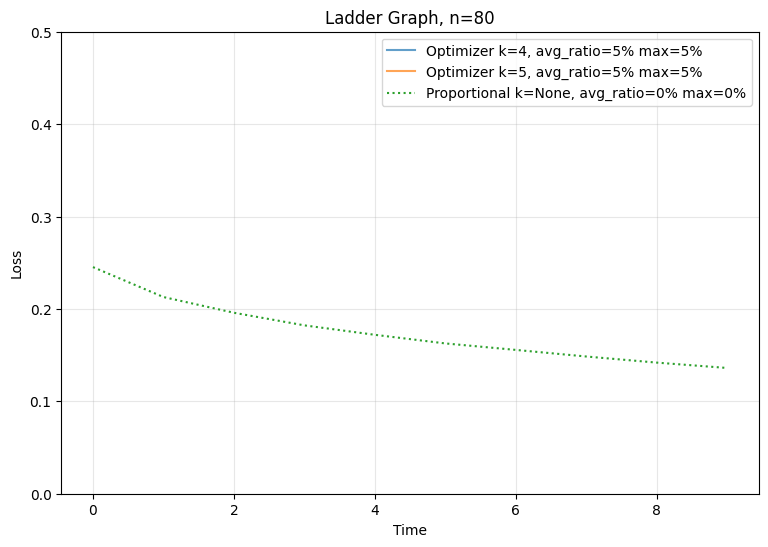

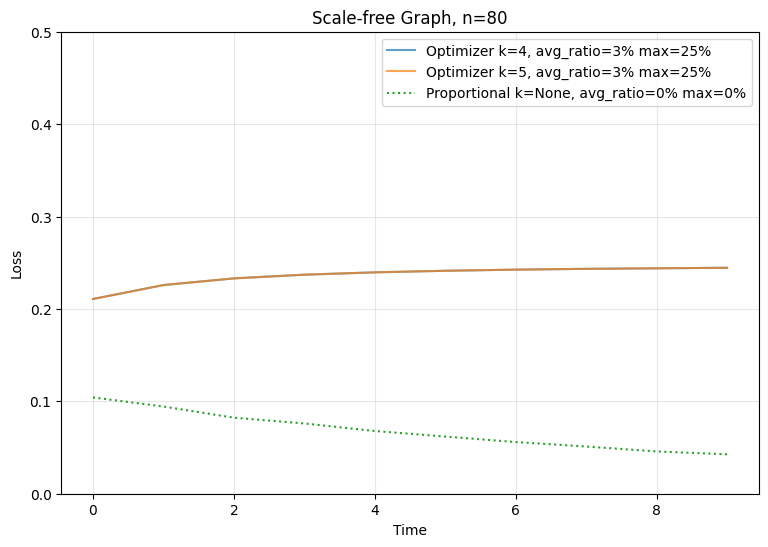

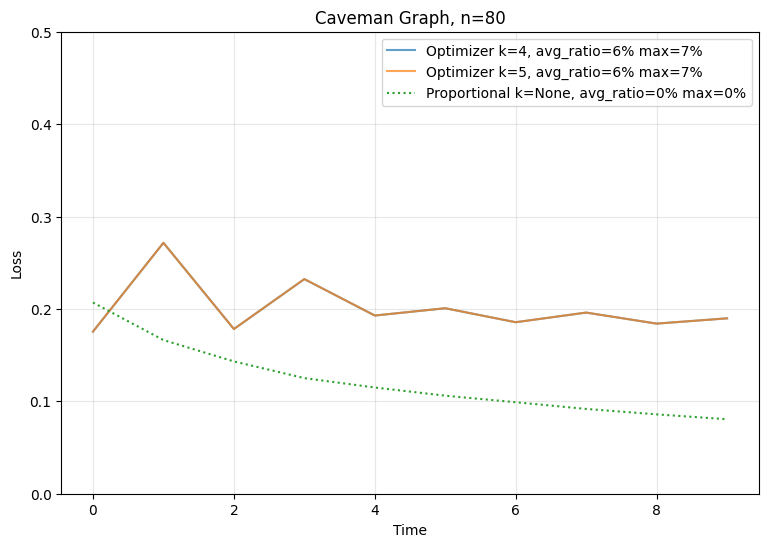

In [24]:
# window = (5, min(simulation_duration, 50))
window = (0, 10)
time_steps = np.arange(window[0], window[1])
benchmarks = ["Optimal", "Proportional", "Proportional - Volitile Market"]

k_mask = [
    1,
    # 2,
    # 3,
    # 4,
    # 5
]
agent_mask = ["Optimal"]


def filter(array):
    mutated = np.array(array)
    mean = np.mean(mutated[mutated <= 1.0])
    mutated[mutated > 1.0] = None
    n_fixed = array[array > 1.0].size
    if n_fixed > 0:
        print(f"removed {n_fixed} values")
    return mutated


for graph_type in markets.keys():
    plt.figure(figsize=(9, 6))
    axis = plt.gca()
    axis.set_ylim(0.0, 0.5)

    for entry in markets[graph_type]:
        if entry["k"] in k_mask or entry["agent_strategy"] in agent_mask:
            continue
        data = entry["simulation_result"][window[0] : window[1]]
        # data = filter(data)
        avg_ratio_prct = (
            int(entry["avg_market_ratio"] * 100)
            if entry["avg_market_ratio"] is not None
            else 0
        )
        max_ratio_prct = (
            int(entry["max_market_ratio"] * 100)
            if entry["avg_market_ratio"] is not None
            else 0
        )
        plt.plot(
            time_steps,
            data,
            label=f"{entry['agent_strategy']} k={entry['k']}, avg_ratio={avg_ratio_prct}% max={max_ratio_prct}%",
            alpha=0.7 if entry["agent_strategy"] not in benchmarks else 1.0,
            linestyle="-" if entry["agent_strategy"] not in benchmarks else ":",
        )
        # plt.axhline(y=np.sum(entry["utility_vector"]), color='red', linestyle='--', linewidth=2, label='Optimal utility')
        # plt.axhline(y=np.mean(entry["simulation_result"]), color='blue', linestyle='--', linewidth=2, label='Avg utility')
    plt.xlabel("Time")
    plt.ylabel("Loss")
    plt.title(f"{graph_type} Graph, n={market_size}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()